In [1]:
# Celda 1: Importar librerías necesarias
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
sns.set_theme(style="whitegrid")

In [9]:
# Celda 2: Cargar y estructurar los datos
file_path = '/home/momin/Documents/aisupportagent/SwissLife-2026/jira_hackathon_blind_eval_challenge_20260923083915-1141.json'

with open(file_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# El JSON contiene metadatos globales, pero los tickets están en la clave 'records'
df = pd.DataFrame(raw_data['records'])

print(f"Metadatos del JSON - ID de ejecución: {raw_data.get('runId')}")
print(f"Total de tickets cargados: {len(df)}")

# Mostrar las primeras 3 filas para verificar la estructura
display(df)

Metadatos del JSON - ID de ejecución: 20260923083915-1141
Total de tickets cargados: 20


,Work type,Request type,Summary,Description,Affected Business or IT Services,Business Entity,Business Critical for Entity,Service Team(s),Reporter,Assignee,...,Urgency,Impact,Severity,Created date,Status,Linked issues,Resolution,Due date,Resolution date,All Comments
0,Service Request,New License,New license requested for quarterly withholdin...,The operations team needs one additional user ...,[Tax Reporting],[Germany],[],[],amelia.marcus@intcom.com,None,...,Lowest,High,None,2026-09-18 23:36,open,[],None,None,None,[amelia.marcus@intcom.com: Request is for the ...
1,Service Request,Access to a Service,Access requested for Portfolio Accounting to s...,A new operations joiner needs standard Portfol...,[Portfolio Accounting],[Luxembourg],[],[],maia.berg@intcom.com,None,...,High,High,None,2026-09-18 16:50,open,[],None,None,None,[maia.berg@intcom.com: Standard processing acc...
2,Service Request,New License,New license requested for sanctions screening ...,A new compliance analyst needs a standard lice...,[Risk & Compliance Monitoring],[Germany],[],[],maia.berg@intcom.com,None,...,High,High,None,2026-09-17 06:12,open,[],None,None,None,[maia.berg@intcom.com: Standard compliance ana...
3,Incident,Email / 3rd Party Warning,Custodian notice says MT536 settlement status ...,A custodian notice reports delayed MT536 settl...,[Securities Settlement],[France],[],[],info@extcom_08.com,None,...,Lowest,Medium,None,2026-09-11 11:14,open,[],None,None,None,[info@extcom_08.com: MT536 settlement status m...
4,Incident,Machine Created Alert,Trade matching adapter TMA-402 rejected 16 all...,The TMA-402 trade matching adapter rejected 16...,[Trade Matching],[Luxembourg],[],[],sa_securities@intcom.com,None,...,Medium,Low,None,2026-09-11 04:16,open,[BROKER-93623],None,None,None,[sa_securities@intcom.com: Adapter TMA-402 rej...
5,Incident,Human Created Incident,Client report PDFs for the Nordics entity were...,The client reporting team observed that the la...,[Client Reporting],[Nordics],[],[],nadia.morgan@intcom.com,None,...,Medium,Low,None,2026-09-22 07:05,open,[REP-20247],None,None,None,[nadia.morgan@intcom.com: Preview looked corre...
6,Incident,Nonsense / Unclear Input,Cash not there pls fix asap for yesterday marg...,The reporter entered a short and unclear messa...,[Cash Management],[Nordics],[],[],helen.smith@intcom.com,None,...,Highest,High,None,2026-09-13 18:27,open,[],None,None,None,[helen.smith@intcom.com: Margin cash looked wr...
7,Incident,Email / 3rd Party Warning,Rimes overnight benchmark file DM_RIMES_FU_PR_...,Rimes Client Managed Services reported that th...,[Rimes Data Feed],[Germany],[],[],info@extcom_11.com,None,...,High,High,None,2026-09-16 04:20,open,[SLAPSA-135158],None,None,None,[info@extcom_11.com: Late feed delivery update...
8,Incident,Email / 3rd Party Warning,Vendor notice: Americas benchmark publication ...,An external vendor warning states that the Ame...,[SharePoint & File Storage],[Luxembourg],[],[],info@extcom_15.com,None,...,Low,Medium,None,2026-09-11 15:04,open,[],None,None,None,[info@extcom_15.com: Delayed benchmark publica...
9,Service Request,Email / 3rd Party Warning,Vendor onboarding mail says LEI submission fil...,A vendor onboarding mail was forwarded into Ji...,[CRM & Client Portal],[Luxembourg],[],[],info@extcom_20.com,None,...,Medium,High,None,2026-09-21 14:53,open,[],None,None,None,[info@extcom_20.com: Submission file rejected ...


In [4]:
# Celda 3: Limpieza y transformación de datos
# Algunas columnas como 'Business Entity' o 'Affected Business or IT Services' son listas. 
# Las convertimos a strings separados por comas para facilitar su agrupación.

columnas_lista = ['Affected Business or IT Services', 'Business Entity', 'Linked issues']

for col in columnas_lista:
    df[col] = df[col].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

# Convertir 'Created date' a formato datetime para análisis temporal
df['Created date'] = pd.to_datetime(df['Created date'])

In [5]:
# Celda 4: Análisis de Tipos de Trabajo y Tipos de Solicitud
print("--- Resumen por Work type ---")
display(df['Work type'].value_counts())

print("\n--- Resumen por Request type ---")
display(df['Request type'].value_counts())

--- Resumen por Work type ---


Work type
Incident           13
Service Request     7
Name: count, dtype: int64


--- Resumen por Request type ---


Request type
Machine Created Alert                  5
Email / 3rd Party Warning              4
Human Created Incident                 3
New License                            2
Access to a Service                    2
Nonsense / Unclear Input               1
Access Removal                         1
Misclassified Incident Title           1
Misclassified Service Request Title    1
Name: count, dtype: int64

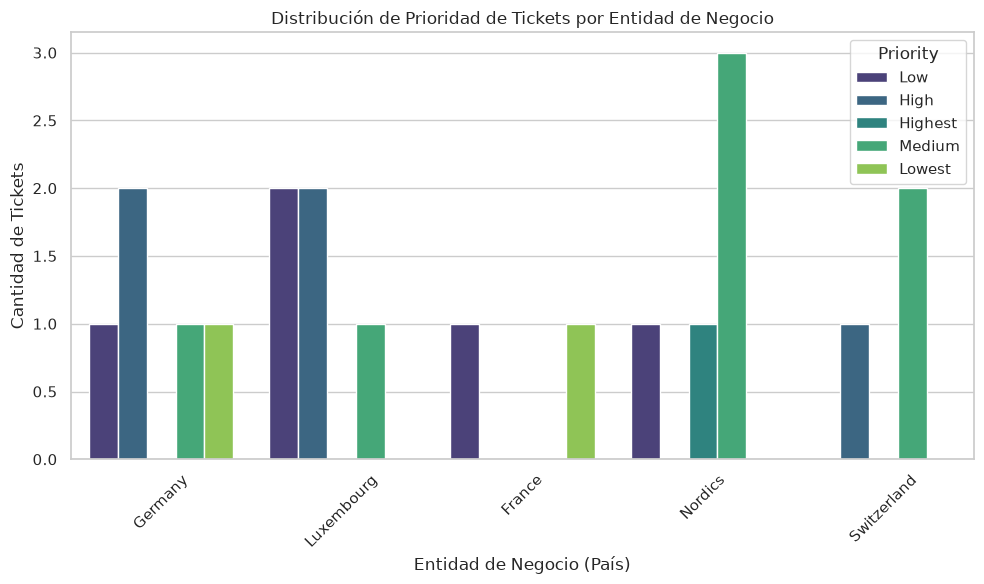

In [6]:
# Celda 5: Visualización - Distribución de Prioridad por Entidad de Negocio
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Business Entity', hue='Priority', palette='viridis')

plt.title('Distribución de Prioridad de Tickets por Entidad de Negocio')
plt.xlabel('Entidad de Negocio (País)')
plt.ylabel('Cantidad de Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Celda 6: Análisis de los tickets generados por máquinas vs humanos
# Filtramos para ver qué incidentes vienen de alertas automatizadas
alertas_maquina = df[df['Request type'] == 'Machine Created Alert']

print(f"Total de alertas automatizadas: {len(alertas_maquina)}")
display(alertas_maquina[['Summary', 'Affected Business or IT Services', 'Priority']])

Total de alertas automatizadas: 5


,Summary,Affected Business or IT Services,Priority
4,Trade matching adapter TMA-402 rejected 16 all...,Trade Matching,Low
10,SimCorp replication job SCD_POS_SYNC failed on...,SimCorp Dimension,Medium
11,NAV_EOD_GE_375 stopped after valuation toleran...,NAV Calculation,Medium
16,Corporate action ingestion CAEV-874 is missing...,Corporate Actions,High
18,Settlement confirmation queue SECLINK-7549 bac...,Securities Settlement,Medium
